## Exploratory Data Analysis

In [16]:
import pandas as pd

df = pd.read_csv("../data/startup_success_dataset.csv")
df.head()

,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million,investor_type,sector,founder_background,outcome
0,4,13,58,48.225483,594843,18.519211,1.483962e+06,tier2_vc,Health,academic,IPO
1,1,6,221,31.532647,393020,14.298149,8.620568e+05,tier2_vc,Fintech,first_time,Failure
2,3,5,247,4.969722,27636,20.447567,9.726169e+04,none,SaaS,first_time,Failure
3,3,14,229,3.084209,235376,8.177417,1.145785e+06,none,Ecommerce,ex_bigtech,Acquisition
4,1,17,235,13.818188,391765,4.879792,8.608949e+05,none,Health,first_time,Acquisition


In [9]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (100000, 11)

Missing values:
 funding_rounds              0
founder_experience_years    0
team_size                   0
market_size_billion         0
product_traction_users      0
burn_rate_million           0
revenue_million             0
investor_type               0
sector                      0
founder_background          0
outcome                     0
dtype: int64

Duplicate rows: 0


In [10]:
# Check information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   funding_rounds            100000 non-null  int64  
 1   founder_experience_years  100000 non-null  int64  
 2   team_size                 100000 non-null  int64  
 3   market_size_billion       100000 non-null  float64
 4   product_traction_users    100000 non-null  int64  
 5   burn_rate_million         100000 non-null  float64
 6   revenue_million           100000 non-null  float64
 7   investor_type             100000 non-null  object 
 8   sector                    100000 non-null  object 
 9   founder_background        100000 non-null  object 
 10  outcome                   100000 non-null  object 
dtypes: float64(3), int64(4), object(4)
memory usage: 8.4+ MB


In [11]:
df.describe(include='all')

,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million,investor_type,sector,founder_background,outcome
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000,100000,100000,100000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,7,4,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tier2_vc,Crypto,first_time,Failure
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35327,14456,39980,55610
mean,2.002300,12.024300,150.732000,33.203875,285422.832730,16.776213,7.828191e+05,NaN,NaN,NaN,NaN
std,1.414671,7.208089,86.272631,43.034753,159323.885405,15.711368,6.085069e+05,NaN,NaN,NaN,NaN
min,0.000000,0.000000,2.000000,0.288738,668.000000,0.279763,1.344810e+03,NaN,NaN,NaN,NaN
25%,1.000000,6.000000,76.000000,10.196778,161194.750000,7.087591,3.154861e+05,NaN,NaN,NaN,NaN
50%,2.000000,12.000000,151.000000,20.158063,264989.500000,12.169059,6.213624e+05,NaN,NaN,NaN,NaN
75%,3.000000,18.000000,226.000000,39.531967,389214.000000,20.953561,1.098921e+06,NaN,NaN,NaN,NaN


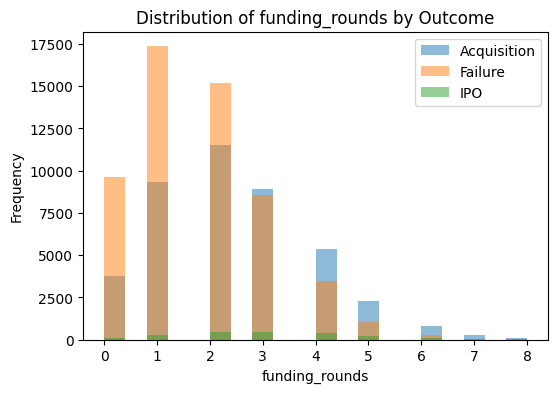

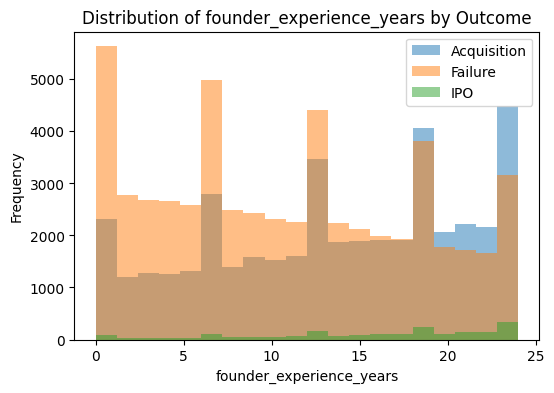

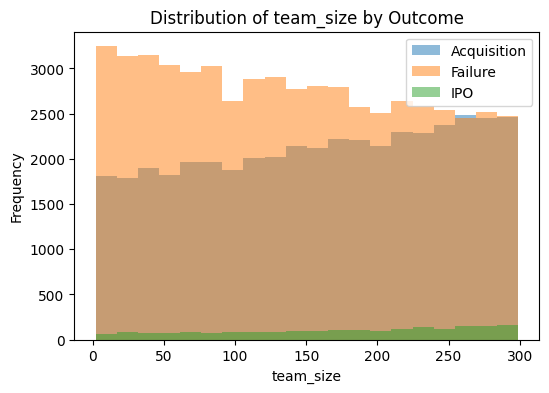

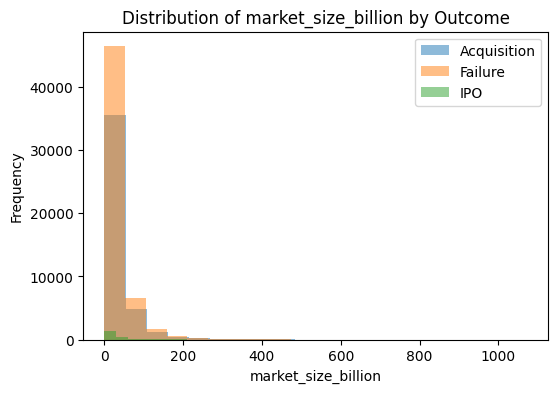

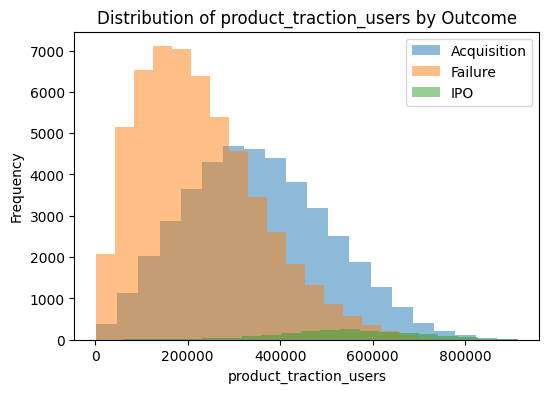

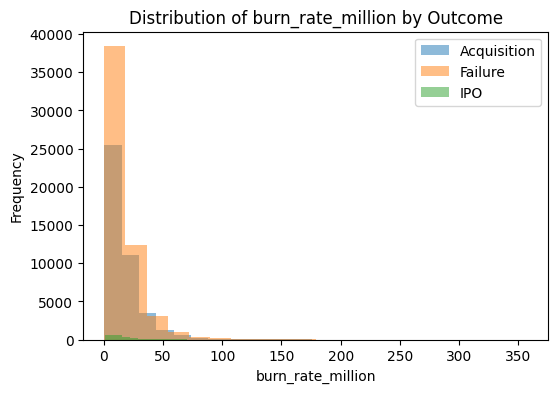

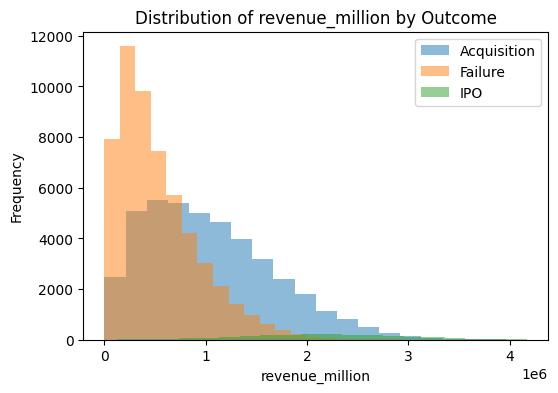

In [15]:
# Outliers
import matplotlib.pyplot as plt

features = [
    "funding_rounds",
    "founder_experience_years",
    "team_size",
    "market_size_billion",
    "product_traction_users",
    "burn_rate_million",
    "revenue_million"
]

for feature in features:
    plt.figure(figsize=(6,4))

    # loop through each outcome category (Acquisition / Failure / IPO)
    for outcome_class in sorted(df['outcome'].unique()):
        plt.hist(
            df[df['outcome'] == outcome_class][feature],
            bins=20,
            alpha=0.5,
            label=outcome_class
        )

    plt.title(f"Distribution of {feature} by Outcome")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

In [13]:
# Class Imbalance
print(df['outcome'].value_counts())
print(df['outcome'].value_counts(normalize=True))

outcome
Failure        55610
Acquisition    42335
IPO             2055
Name: count, dtype: int64
outcome
Failure        0.55610
Acquisition    0.42335
IPO            0.02055
Name: proportion, dtype: float64


In [14]:
# Target Variable Chosen: Outcome
# Check target variable distribution
print(df['outcome'].value_counts())

# Check proportions (better for class imbalance)
print(df['outcome'].value_counts(normalize=True))

outcome
Failure        55610
Acquisition    42335
IPO             2055
Name: count, dtype: int64
outcome
Failure        0.55610
Acquisition    0.42335
IPO            0.02055
Name: proportion, dtype: float64
